In [55]:
from luna16_helpers import load_h5_file
import os
import numpy as np
import torch
import torch.nn as nn

import fastnumpyio
import matplotlib.pyplot as plt


In [46]:
# extracting the bin files into .npy arrays
if not os.path.exists("files/patches_dataset"):
    os.mkdir("files/patches_dataset")
    
    for class_ in [1,0]:
        scan_path = f"files/bin/{class_}/"
        save_path = f"files/patches_dataset/{class_}/"
        listing = os.listdir(scan_path)
        listing = [fname for fname in listing if fname.endswith('.h5')]
        
        for filename in listing:
            image, mask, metadata = load_h5_file(scan_path + filename)
            labels = [ candidate['label'] for candidate in metadata ]
            labels = np.array(labels, dtype=np.long)
            
            #print(type(image))
            #print(f"Labels: {labels}")
            #print(f"Image shape: {image.shape}")
            #print(f"Mask shape: {mask.shape}")
            #print(f"Number of candidates in this file: {len(metadata)}")
        
            for candidate_nr in range(len(metadata)):
                #print(f"Metadata for candidate {candidate_nr}: {metadata[candidate_nr]}")
                uid = metadata[candidate_nr]['uid']
                class_label = metadata[candidate_nr]['label']  
                assert(class_label == class_)
                fastnumpyio.save(f"{save_path}{uid}_{class_label}_{candidate_nr}.npy", image[candidate_nr])


In [ ]:
#splitting the dataset

import os
import random

delete = True # for deleting some non-nodules

test_split = 0.3
valid_split = 0.1

if not os.path.exists("files/patches_dataset_split"):
    os.mkdir("files/patches_dataset_split")
    os.mkdir("files/patches_dataset_split/test")
    os.mkdir("files/patches_dataset_split/train")
    os.mkdir("files/patches_dataset_split/validate")

    classes = os.listdir("files/patches_dataset")
    for c in classes:
        print(f"copying class {c}")
        files = os.listdir(f"files/patches_dataset/{c}")
        random.shuffle(files)

        num_images = len(files)
        num_test = int(test_split * num_images)
        num_valid = int(valid_split * num_images)
        num_train = num_images - num_test - num_valid

        os.mkdir(f"files/patches_dataset_split/test/{c}")
        os.mkdir(f"files/patches_dataset_split/train/{c}")
        os.mkdir(f"files/patches_dataset_split/validate/{c}")

        for idx, file in enumerate(files):
            split = 'train' if idx < num_train else 'validate' if idx < num_train + num_valid else 'test'
            x = fastnumpyio.load(f"files/patches_dataset/{c}/{file}")
            fastnumpyio.save(f"files/patches_dataset_split/{split}/{c}/{file}", x)


if delete:
    train_files_0 = os.listdir(f"files/patches_dataset_split/train/0")
    train_files_1 = os.listdir(f"files/patches_dataset_split/train/1")

    if len(train_files_0) > 5*len(train_files_1):
        random.shuffle(train_files_0)
        for file in train_files_0[5*len(train_files_1):]:
            os.remove(f"files/patches_dataset_split/train/0/{file}")


In [48]:
from torchvision.datasets import DatasetFolder
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

batch_size = 32

train_dataset = DatasetFolder("files/patches_dataset_split/train", fastnumpyio.load, "npy", transform)
val_dataset = DatasetFolder("files/patches_dataset_split/validate", fastnumpyio.load, "npy", transform)
test_dataset = DatasetFolder("files/patches_dataset_split/test", fastnumpyio.load, "npy", transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                           
            # output size: 16 x 32 x 32 
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                            
            # output size: 32 x 16 x 16 
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
            # output size: 64 x 8 x 8                         
        )

        self.flatten = nn.Flatten()

        self.classifier = nn.Sequential(
            nn.Linear(8 * 8 * 64, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        out = self.features(x)
        out = self.flatten(out)
        out = self.classifier(out)
        return out


In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

model = CNN().to(device)
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1/10, 1]))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


Using cpu device


In [62]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            loss_sum += loss.item()

    acc = correct / total
    return loss_sum / len(loader), acc


In [ ]:
epochs = 10

for epoch in range(1,epochs+1):
    train_loss = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, valid_loader)

    torch.save(model.state_dict(), f"files/models/CNN_IAML_afterEpoch{epoch}.pth")

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")
    

Epoch 1/10 | Train Loss: 1.9745 | Val Loss: 0.4884 | Val Acc: 0.7811
Epoch 2/10 | Train Loss: 0.4242 | Val Loss: 0.7115 | Val Acc: 0.6683
Epoch 3/10 | Train Loss: 0.3489 | Val Loss: 0.6539 | Val Acc: 0.7004
Epoch 4/10 | Train Loss: 0.2851 | Val Loss: 0.5049 | Val Acc: 0.7988
Epoch 5/10 | Train Loss: 0.2829 | Val Loss: 0.5812 | Val Acc: 0.7790
Epoch 6/10 | Train Loss: 0.2357 | Val Loss: 0.5222 | Val Acc: 0.7905
Epoch 7/10 | Train Loss: 0.2055 | Val Loss: 0.2272 | Val Acc: 0.9186
Epoch 8/10 | Train Loss: 0.1893 | Val Loss: 0.1661 | Val Acc: 0.9441
Epoch 9/10 | Train Loss: 0.1613 | Val Loss: 0.5108 | Val Acc: 0.8177
Epoch 10/10 | Train Loss: 0.1473 | Val Loss: 0.2817 | Val Acc: 0.9027


Accuracy on test set: 89.96%


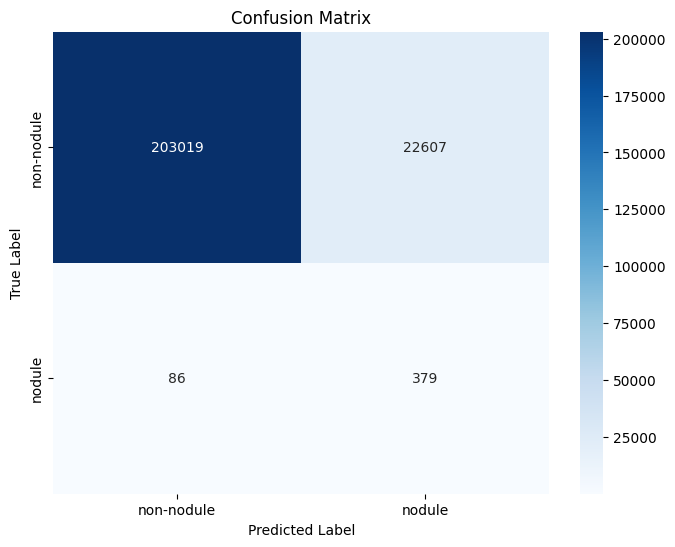

In [64]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.eval()

classes = ['non-nodule', 'nodule']

all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())
    

# concatenate all batches
all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

# confusion matrix
confmat = confusion_matrix(all_targets, all_preds)

# show confusion matrix
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(confmat, annot=True, fmt='g', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# calculate accuracy from confusion matrix

accuracy = np.diag(confmat).sum() / confmat.sum()
print(f'Accuracy on test set: {accuracy.item()*100:.2f}%')

In [ ]:
# Metrics

# Accuracy
# Sensitivity

print(confmat)

confmat = [[], []] ....

[[203019  22607]
 [    86    379]]
